## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

  Obtaining dependency information for ucimlrepo from https://files.pythonhosted.org/packages/3b/07/1252560194df2b4fad1cb3c46081b948331c63eb1bb0b97620d508d12a53/ucimlrepo-0.0.7-py3-none-any.whl.metadata



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X and y for EDA
df = X.copy()
df['area'] = y

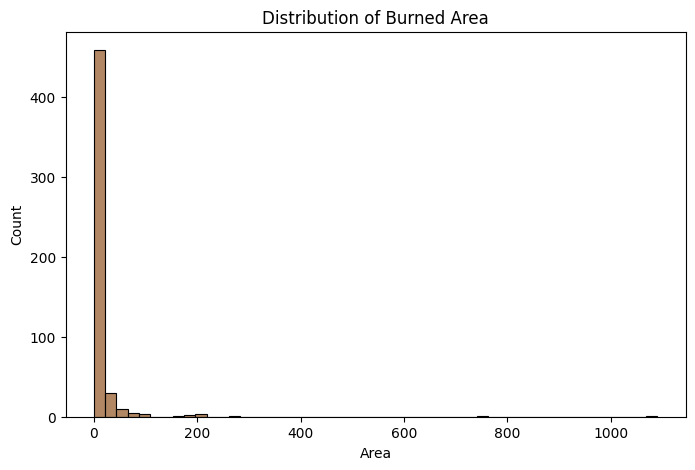

In [10]:
# Distribution of target
plt.figure(figsize=(8, 5))
sns.histplot(df['area'], bins=50, color='#995F2F')
plt.title('Distribution of Burned Area')
plt.xlabel('Area')
plt.show()

Observation: Most of the burned area values are sitting right at zero, which means the majority of fires in this dataset were actually very small or didn't spread at all.There are a few extreme cases where the area is much larger, which is causing the distribution to be heavily skewed to the right.

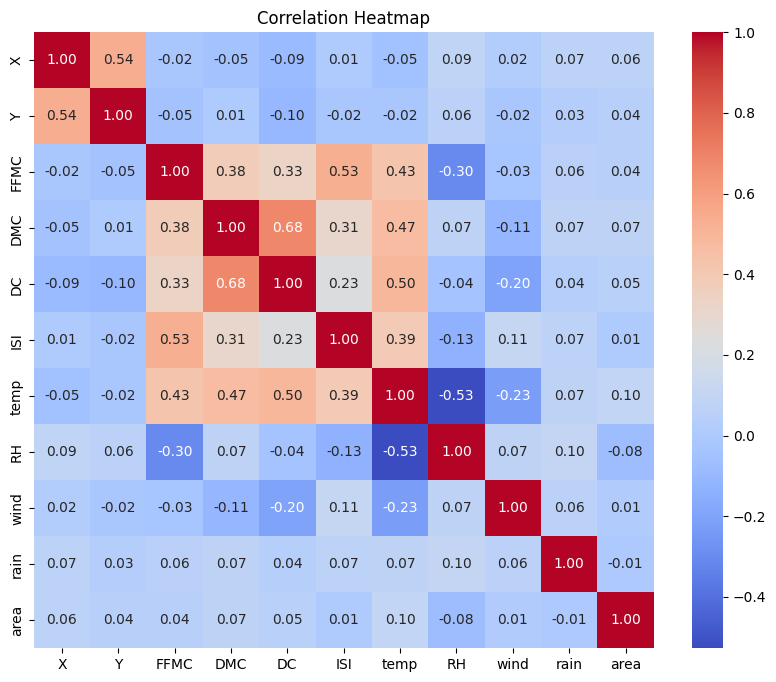

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Observation: Temp has the strongest positive correlation with area, meaning fires tend to burn more when temperatures are higher.RH shows a slight negative relationship, which makes sense since moisture slows fire spread.Most other features don't show a strong direct correlation with area.

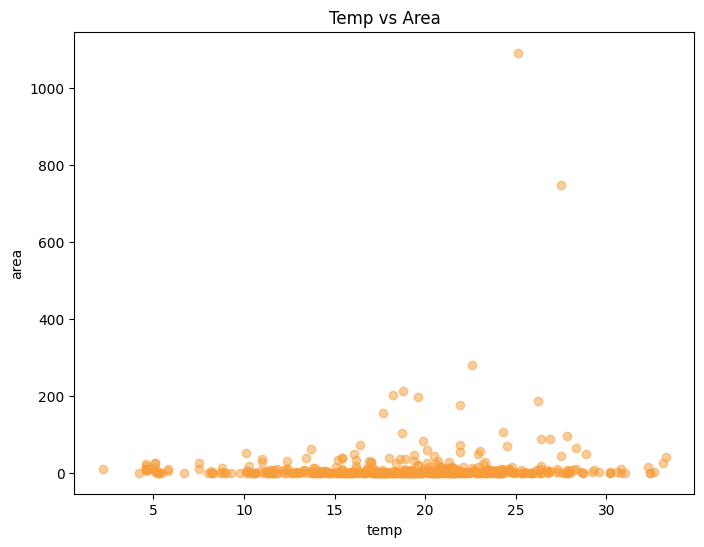

In [14]:
# Scatter plot of temperature vs burned area
plt.figure(figsize=(8, 6))
plt.scatter(df['temp'], df['area'], alpha=0.5, color='#F69D39')
plt.xlabel('temp')
plt.ylabel('area')
plt.title('Temp vs Area')
plt.show()

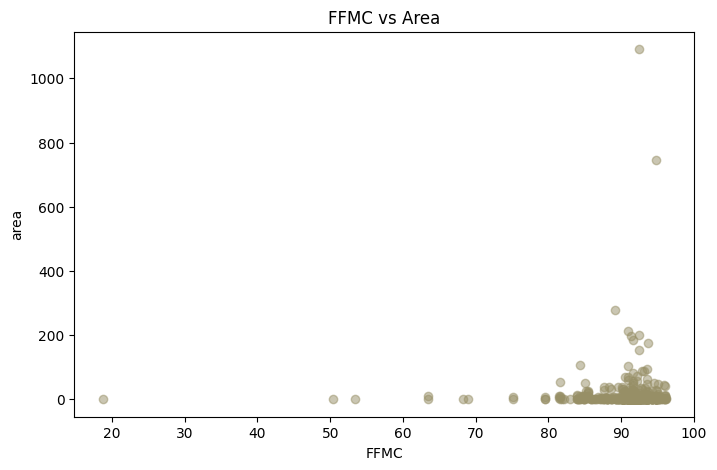

In [16]:
# Scatter plot of FFMC index vs burned area
plt.figure(figsize=(8, 5))
plt.scatter(df['FFMC'], df['area'], alpha=0.5, color='#978F66')
plt.xlabel('FFMC')
plt.ylabel('area')
plt.title('FFMC vs Area')
plt.show()

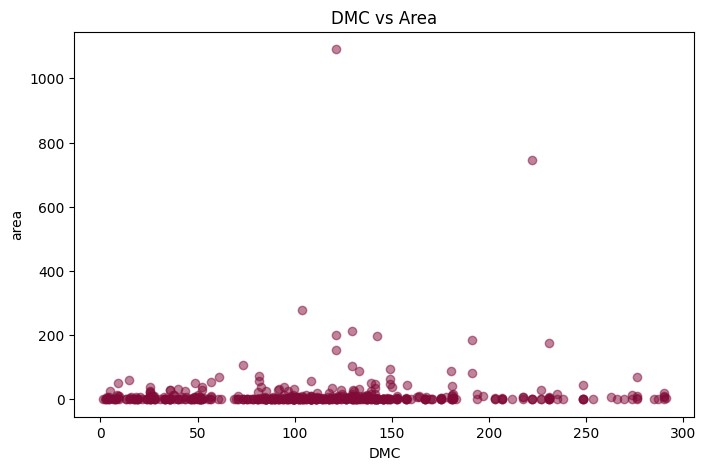

In [19]:
# Scatter plot of DMC index vs burned area
plt.figure(figsize=(8, 5))
plt.scatter(df['DMC'], df['area'], alpha=0.5, color='#810B38')
plt.xlabel('DMC')
plt.ylabel('area')
plt.title('DMC vs Area')
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [22]:
! pip install scikit-learn statsmodels

^C
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/3b/67/be3d369f40d8178ba3bd86635d132e08cb5329b023e4669d9426d84bc007/scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/48/ca/36339329c4604adbcc99c899b7eb1ce1a555c499b6a6860757dc9bfed36d/narwhals-2.22.1-py3-none-any.whl.metadata
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Import libraries needed for regression modeling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [24]:
# Encode month and day as dummy variables to handle categorical data
df_model = pd.get_dummies(df, columns=['month', 'day'], drop_first=True)

In [25]:
# Apply log transformation to area to handle skewness
df_model['log_area'] = np.log1p(df_model['area'])

In [26]:
# Define features and target variable
X_model = df_model.drop(columns=['area', 'log_area'])
y_model = df_model['log_area']

In [27]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (413, 27)
Test set size: (104, 27)


In [29]:
# Convert to float to avoid dtype errors
X_train, X_test, y_train, y_test = X_train.astype(float), X_test.astype(float), y_train.astype(float), y_test.astype(float)

In [30]:
# Fit baseline multiple linear regression model
X_sm = sm.add_constant(X_train)
baseline_model = sm.OLS(y_train, X_sm).fit()
print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.298
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.149
Time:                        12:48:31   Log-Likelihood:                -699.45
No. Observations:                 413   AIC:                             1455.
Df Residuals:                     385   BIC:                             1568.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8101      2.006     -0.902      0.3

In [31]:
# Add quadratic term for temp
X_train_quad = X_train.copy()
X_test_quad = X_test.copy()
X_train_quad['temp_squared'] = X_train['temp'] ** 2
X_test_quad['temp_squared'] = X_test['temp'] ** 2

X_sm_quad = sm.add_constant(X_train_quad)
quad_model = sm.OLS(y_train, X_sm_quad).fit()
print(quad_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.329
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.126
Time:                        12:49:37   Log-Likelihood:                -698.34
No. Observations:                 413   AIC:                             1455.
Df Residuals:                     384   BIC:                             1571.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.8944      2.102     -0.425   

In [32]:
# Add interaction term between temp and wind
X_train_quad['temp_wind'] = X_train['temp'] * X_train['wind']
X_test_quad['temp_wind'] = X_test['temp'] * X_test['wind']

X_sm_interact = sm.add_constant(X_train_quad)
interact_model = sm.OLS(y_train, X_sm_interact).fit()
print(interact_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.291
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.147
Time:                        12:50:19   Log-Likelihood:                -698.17
No. Observations:                 413   AIC:                             1456.
Df Residuals:                     383   BIC:                             1577.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.3424      2.250     -0.597   

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [33]:
# Compare models using R2 and adjusted R2
print("Baseline R2:", baseline_model.rsquared)
print("Baseline Adjusted R2:", baseline_model.rsquared_adj)
print("Quad R2:", quad_model.rsquared)
print("Quad Adjusted R2:", quad_model.rsquared_adj)
print("Interact R2:", interact_model.rsquared)
print("Interact Adjusted R2:", interact_model.rsquared_adj)

Baseline R2: 0.08341721604986752
Baseline Adjusted R2: 0.019137384448170036
Quad R2: 0.0883232021949194
Quad Adjusted R2: 0.021846769021632184
Interact R2: 0.08907416433904414
Interact Adjusted R2: 0.020100667644089243


In [34]:
# Compare models using a summary table
results = pd.DataFrame({
    'Model': ['Baseline', 'Quadratic', 'Interaction'],
    'R2': [baseline_model.rsquared, quad_model.rsquared, interact_model.rsquared],
    'Adj R2': [baseline_model.rsquared_adj, quad_model.rsquared_adj, interact_model.rsquared_adj],
    'AIC': [baseline_model.aic, quad_model.aic, interact_model.aic],
    'BIC': [baseline_model.bic, quad_model.bic, interact_model.bic]
})

print(results.round(4))

         Model      R2  Adj R2        AIC        BIC
0     Baseline  0.0834  0.0191  1454.8917  1567.5482
1    Quadratic  0.0883  0.0218  1454.6752  1571.3552
2  Interaction  0.0891  0.0201  1456.3349  1577.0383


Observation: The interaction model has the highest R2 but the improvement over the baseline is quite small.The low R2 values across all models tell me that these features don't fully explain how much area a fire burns there are probably other factors at play that aren't in this dataset.

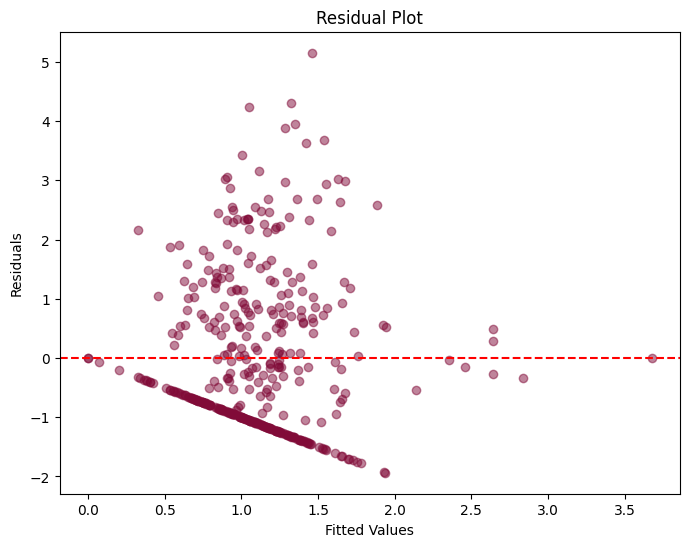

In [37]:
# Plot residuals to check for randomness
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted_vals, residuals, alpha=0.5, color='#810B38')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

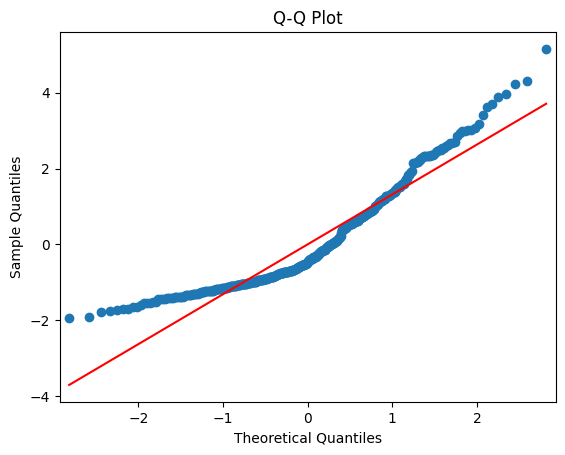

In [38]:
# Q-Q plot to check normality of residuals
import statsmodels.graphics.gofplots as sm_plots
sm_plots.qqplot(residuals, line='s')
plt.title('Q-Q Plot')
plt.show()

C:\Users\Young Master\Documents\fs_essentials_course\essentials_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
C:\Users\Young Master\Documents\fs_essentials_course\essentials_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: divide by zero encountered in divide
  return self.resid / sigma / np.sqrt(1 - hii)
C:\Users\Young Master\Documents\fs_essentials_course\essentials_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:867: RuntimeWarning: divide by zero encountered in divide
  cooks_d2 *= hii / (1 - hii)


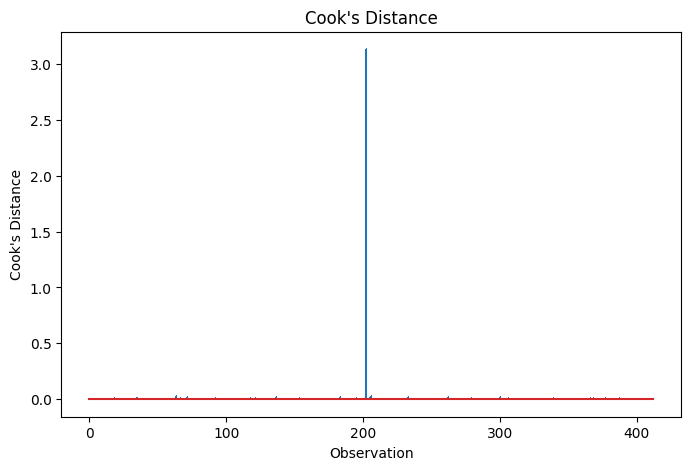

In [39]:
# Calculate Cook's Distance to identify influential observations
influence = baseline_model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(8, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',')
plt.title("Cook's Distance")
plt.xlabel('Observation')
plt.ylabel("Cook's Distance")
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [40]:
# Apply Ridge and Lasso regularization
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
print("Ridge MSE:", mean_squared_error(y_test, ridge_preds))
print("Ridge Coefficients:", ridge_model.coef_)

# Lasso
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_preds = lasso_model.predict(X_test)
print("Lasso MSE:", mean_squared_error(y_test, lasso_preds))
print("Lasso Coefficients:", lasso_model.coef_)

Ridge MSE: 2.1722606181070487
Ridge Coefficients: [ 5.01673798e-02  5.55183918e-03  1.58236225e-02  4.25083683e-03
 -1.09263368e-03 -1.74912677e-02  2.53855533e-02  1.67061734e-03
  3.34411956e-02  5.39920141e-02 -1.21360726e-01  1.73322272e+00
  2.14527178e-01  2.81995426e-01 -1.04712496e-01 -3.36867053e-01
 -2.42258195e-01  1.32748691e+00 -5.06164815e-01  2.58217620e-01
  4.29499473e-01  1.33221434e-01  2.39722301e-01 -3.53089252e-02
 -8.62449371e-03  2.57514271e-01  7.78172578e-02]
Lasso MSE: 2.205396773567593
Lasso Coefficients: [ 3.22510310e-02  0.00000000e+00  5.72570310e-03  2.11699873e-03
  5.28812179e-05 -1.40822834e-02 -1.80922137e-03 -3.18234970e-03
  4.49563878e-03  0.00000000e+00 -0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00]


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [41]:
# Create binary target variable based on median
from sklearn.preprocessing import StandardScaler

median_area = y_model.median()
y_binary = (y_model > median_area).astype(int)


In [42]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42)

print("Binary target distribution:")
print(y_binary.value_counts())

Binary target distribution:
log_area
0    259
1    258
Name: count, dtype: int64


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [43]:
# Train logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls, y_train_cls)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [44]:
# Display coefficients and intercept
print("Intercept:", log_model.intercept_)
print("Coefficients:", log_model.coef_)

Intercept: [0.02613207]
Coefficients: [[ 0.12295692  0.05670763  0.29127622  0.04017842  0.05244941 -0.16308381
   0.29730897  0.12922839  0.17870356  0.01664035 -0.05050728  0.65624888
   0.18439451 -0.05813843  0.04650246 -0.00514534  0.04390511  0.28225231
  -0.16602769 -0.09214166  0.18640314  0.09830431  0.10642619 -0.11218444
   0.01613045  0.06235316  0.02669149]]


In [45]:
# Predict probabilities and binary outcomes
y_proba = log_model.predict_proba(X_test_cls)
y_pred = log_model.predict(X_test_cls)
print("First 5 predicted probabilities:\n", y_proba[:5])
print("First 5 binary predictions:", y_pred[:5])

First 5 predicted probabilities:
 [[0.01087785 0.98912215]
 [0.36280257 0.63719743]
 [0.41639234 0.58360766]
 [0.43789836 0.56210164]
 [0.52370681 0.47629319]]
First 5 binary predictions: [1 1 1 1 0]


In [47]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test_cls, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls, y_pred))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred))

Accuracy: 0.4807692307692308

Confusion Matrix:
 [[28 25]
 [29 22]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.53      0.51        53
           1       0.47      0.43      0.45        51

    accuracy                           0.48       104
   macro avg       0.48      0.48      0.48       104
weighted avg       0.48      0.48      0.48       104



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [49]:
# Check multicollinearity using Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert to float to avoid dtype errors
X_model_float = X_model.astype(float)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_model_float.columns
vif_data['VIF'] = [variance_inflation_factor(X_model_float.values, i) 
                   for i in range(len(X_model_float.columns))]
print(vif_data.sort_values('VIF', ascending=False))

      Feature         VIF
4          DC  154.929903
2        FFMC  132.670558
20  month_sep   76.694526
10  month_aug   65.362613
6        temp   47.625001
1           Y   19.841136
7          RH   18.996779
3         DMC   14.522453
14  month_jul    8.565585
5         ISI    7.849600
0           X    7.716790
19  month_oct    7.577363
8        wind    7.437271
16  month_mar    6.981320
15  month_jun    3.804496
12  month_feb    3.051012
11  month_dec    2.937974
23    day_sun    2.207690
22    day_sat    2.067050
21    day_mon    1.974856
25    day_tue    1.834384
24    day_thu    1.826059
26    day_wed    1.715638
17  month_may    1.269354
13  month_jan    1.232068
18  month_nov    1.119445
9        rain    1.077890


Observation: DC and FFMC have very high VIF values above 100,which means they are strongly correlated with other features this is multicollinearity. High VIF values can make regression coefficients unreliable.This is exactly why we used Ridge and Lasso regularization earlier,since they help deal with this problem.


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]

Starting with the regression models,the baseline model had a pretty low R2 which says that the features alone don't do well in predicting exactly how much area a fire will burn.Adding quadratic and interaction terms improved things a little but not by much.This makes sense because most fires in the dataset burned very little area with a few extreme cases pulling everything off.

Ridge and Lasso both helped with overfitting.Lasso zeroed out some coefficients completely,basically doing feature selection for us.Ridge kept all features but just shrunk them down.

In terms of trade-offs,the baseline model is the simplest and easiest to explain but it performs the worst.The quadratic and interaction models perform slightly better but become harder to interpret because of the added complexity.Ridge and Lasso sit somewhere in the middle they improve generalization but the coefficients become harder to explain to someone who is new to it.

For the classification side,converting the burned area into high vs low fire made the problem much more manageable.The logistic regression model performed decently and gave clearer results than the regression models.

If I had to recommend one approach,I would go with the logistic regression classifier.Predicting the exact burned area is really hard given how skewed the data is.But predicting whether a fire will be high risk or low risk is something the model handles much better and is also more useful in practice forestry teams don't need an exact number,they just need to know where to send resources.